## Kaggle Flight Data Analysis Python Project
Analysis and projections of various metrics (Airline, Destination, Arrival Time, etc) for flights in India from a Kaggle dataset using Python.

## Import Python Libraries
Importing Pandas, Numpy, MatPlotLib, and Seaborn for effective data maniuplation and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## Load Dataset
Importing CSV file for Flight Data in India

In [2]:
df = pd.read_csv('airlines_flights_data.csv')

## Exploring Data Frames
Displaying data to understand data formmating and structure
We see that thrre are 300,152 rows with 11 columns; 4 are integers/floats and 7 are strings

In [3]:
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


## Data Cleaning
Removing redundant Index column and assigning it to new dataframe

In [ ]:
df_cleaned = df.drop(columns=['index'])
df_cleaned.head(12)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954
9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954


Checking for null or duplicate values

In [5]:
df.isnull().sum()
## No null values found

index               0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [6]:
df[df.duplicated()] 
## No duplicate values found

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price


## Feature Engineering
Adding column that has price in USD.

In [7]:
df_cleaned['price (USD $)'] = (df_cleaned['price'] * .012).round(2)
df_cleaned[['price (USD $)']].head(12)

,price (USD $)
0,71.44
1,71.44
2,71.47
3,71.46
4,71.46
5,71.46
6,72.72
7,72.72
8,71.45
9,71.45


Adding column that has price per hour in USD.

In [8]:
df_cleaned['price per hour (USD $)'] = (df_cleaned['price (USD $)'] / df_cleaned['duration']).round(2)
df_cleaned[['price per hour (USD $)']].head(12)

,price per hour (USD $)
0,32.92
1,30.66
2,32.94
3,31.76
4,30.67
5,30.67
6,34.96
7,33.51
8,32.93
9,31.76


## Summary Statistics
Mean, Median, Quartiles, etc

In [9]:
df_cleaned.describe()

,duration,days_left,price,price (USD $),price per hour (USD $)
count,300153.000000,300153.000000,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523,250.676072,26.105617
std,7.191997,13.561004,22697.767366,272.373277,32.801169
min,0.830000,1.000000,1105.000000,13.260000,1.240000
25%,6.830000,15.000000,4783.000000,57.400000,5.520000
50%,11.250000,26.000000,7425.000000,89.100000,11.740000
75%,16.170000,38.000000,42521.000000,510.250000,34.710000
max,49.830000,49.000000,123071.000000,1476.850000,341.680000


## Categorical Variable Exploratory Data Analysis
Let's start by finding the airline frequencies in the dataset

In [10]:
df_cleaned['airline'].value_counts()
## Let's graph this to get a better visualization of the spread.

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

Airline Frequency Bar Graph

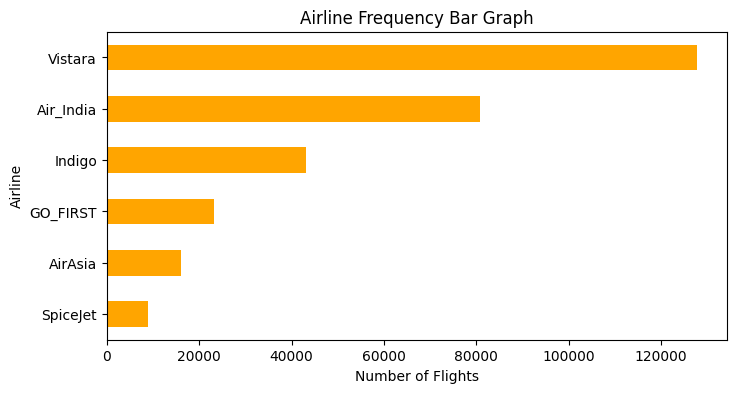

In [ ]:
df_cleaned['airline'].value_counts(ascending = True).plot.barh(color='orange', figsize=(8,4))
plt.title('Airline Frequency Bar Graph')
plt.xlabel('Number of Flights')
plt.ylabel('Airline')
plt.show()

Vistara is the most flown airline and SpiceJet is the least flown.
This can be due to price, quality, destinations, flight timings, or more. 
We'll explore this further in the analysis portion.

Departure and Arrival Time Bar Graphs using Subplot Feature

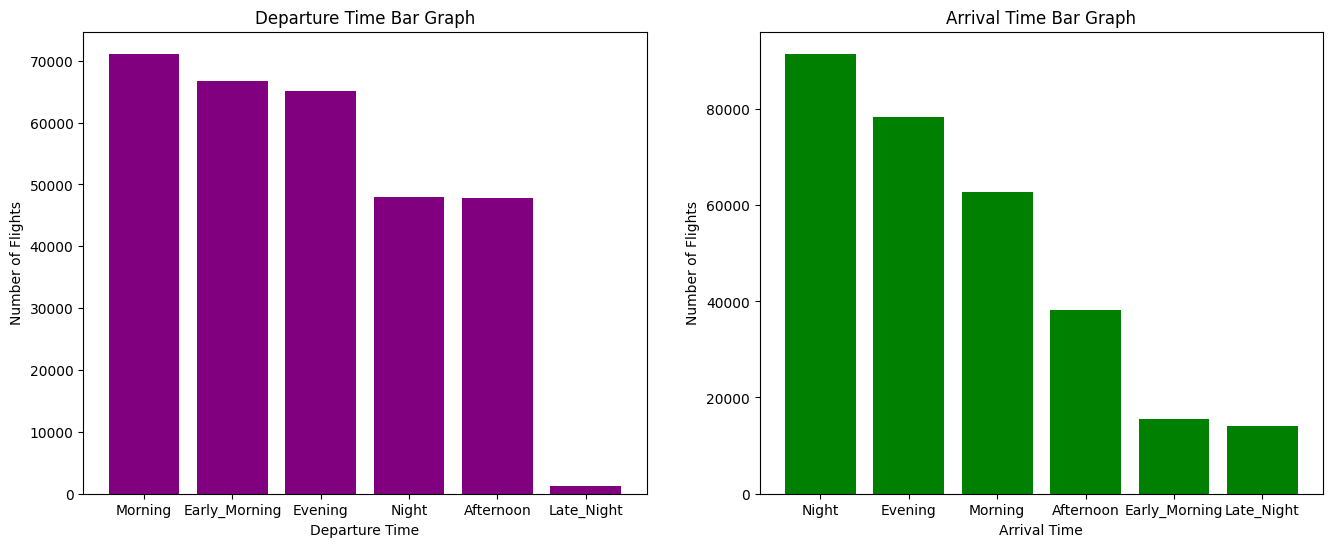

In [ ]:
plt.figure(figsize=(16,6))

plt.subplot(1, 2, 1)
plt.bar(df_cleaned['departure_time'].value_counts().index, df_cleaned['departure_time'].value_counts().values, color='purple')
plt.title('Departure Time Bar Graph')
plt.xlabel('Departure Time')
plt.ylabel('Number of Flights')

plt.subplot(1, 2, 2)
plt.bar(df_cleaned['arrival_time'].value_counts().index, df_cleaned['arrival_time'].value_counts().values, color='green')
plt.title('Arrival Time Bar Graph')
plt.xlabel('Arrival Time')
plt.ylabel('Number of Flights')

plt.show()


Morning is the most common departure time and Late Night is the least common departure time.
Night is the most common arrival time and Late Night is the leas common arrival time.

This information can be helpful for airports who can plan around high and low demand based on flight arrivals and departures. Therefore, airports can anticipate higher demand in the mornings and evenings. 

Source and Destination City Bar Graphs using Subplot Feature

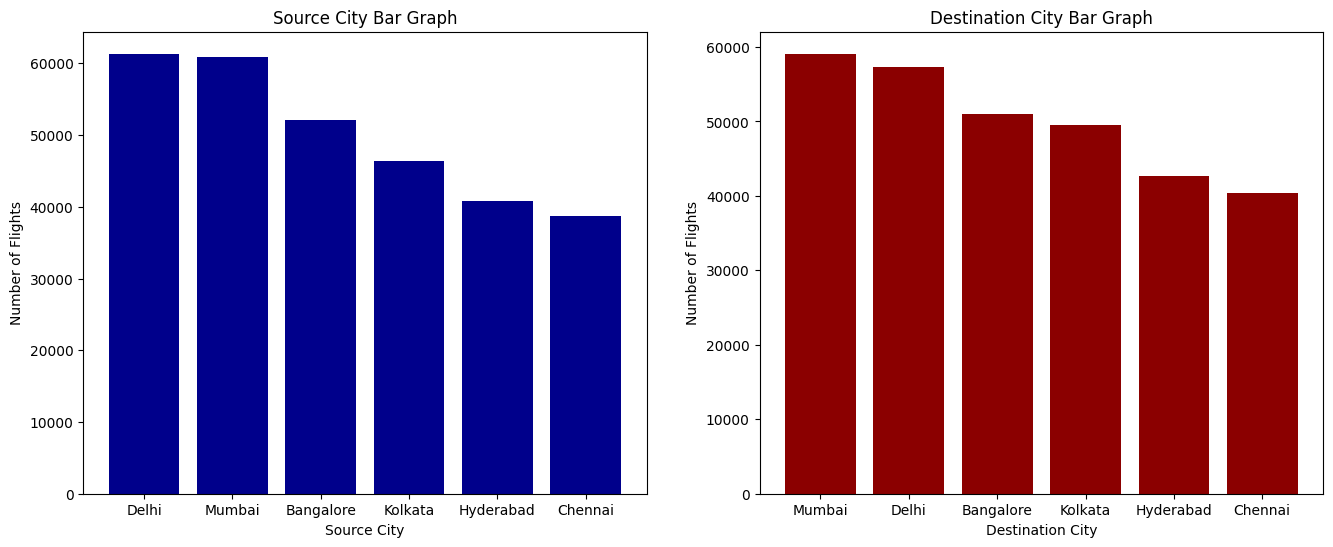

In [ ]:
plt.figure(figsize=(16,6))
plt.subplot(1, 2, 1)

plt.bar(df_cleaned['source_city'].value_counts().index, df_cleaned['source_city'].value_counts().values, color='darkblue')
plt.title('Source City Bar Graph')
plt.xlabel('Source City')
plt.ylabel('Number of Flights')

plt.subplot(1, 2, 2)
plt.bar(df_cleaned['destination_city'].value_counts().index, df_cleaned['destination_city'].value_counts().values, color='darkred')
plt.title('Destination City Bar Graph')
plt.xlabel('Destination City')
plt.ylabel('Number of Flights')

plt.show()


Delhi is the most common source city and Chennai is the least common source city.
Mumbai the most common destination city and Chennai is the least common destination city.

This shows us where the higher populations and more popular tourist destinations in India are, since most flights are between big cities like Delhi and Mumbai, while Hyderabad and Chennai are less populous and visited since they have the least amount of flights.

As shown above, the subplot feature helps combine similar variables into one output

## Airline Price Variation Analysis
Now let's look at the price variations, starting by grouping prices by airline

In [14]:
df_cleaned.groupby('airline')['price'].mean()

airline
AirAsia       4091.072742
Air_India    23507.019112
GO_FIRST      5652.007595
Indigo        5324.216303
SpiceJet      6179.278881
Vistara      30396.536302
Name: price, dtype: float64

Air India and Vistara have much higher average prices than the other airlines, we'll keep an eye out for that in our analysis.

Let's plot these averages using seaborn with different hues to see if we can find the reason

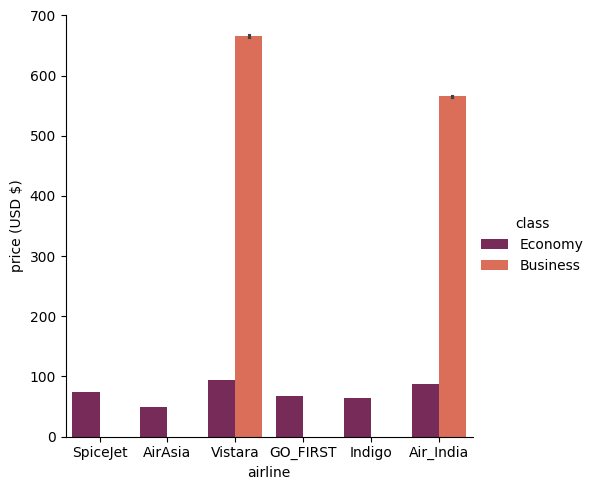

In [15]:
sns.catplot(x='airline', y='price (USD $)', data=df_cleaned, kind='bar', palette='rocket', hue='class')
plt.show()

Looks like the reason Vistara and Air India have much higher averages because they include business class flights as well, which will naturally have higher prices than economy tickets. 

For just economy tickets, AirAsia has the lowest average ticket prices while Vistara has the highest average.
This shows that price is probably not as strong of a predictor for the airline flown, since the most popular airline in this dataset is Vistara, even though it has the highest average ticket price. 
Let's explore further. 

Let's compare this with Price per Hour in a subplot to look at operational efficiency.

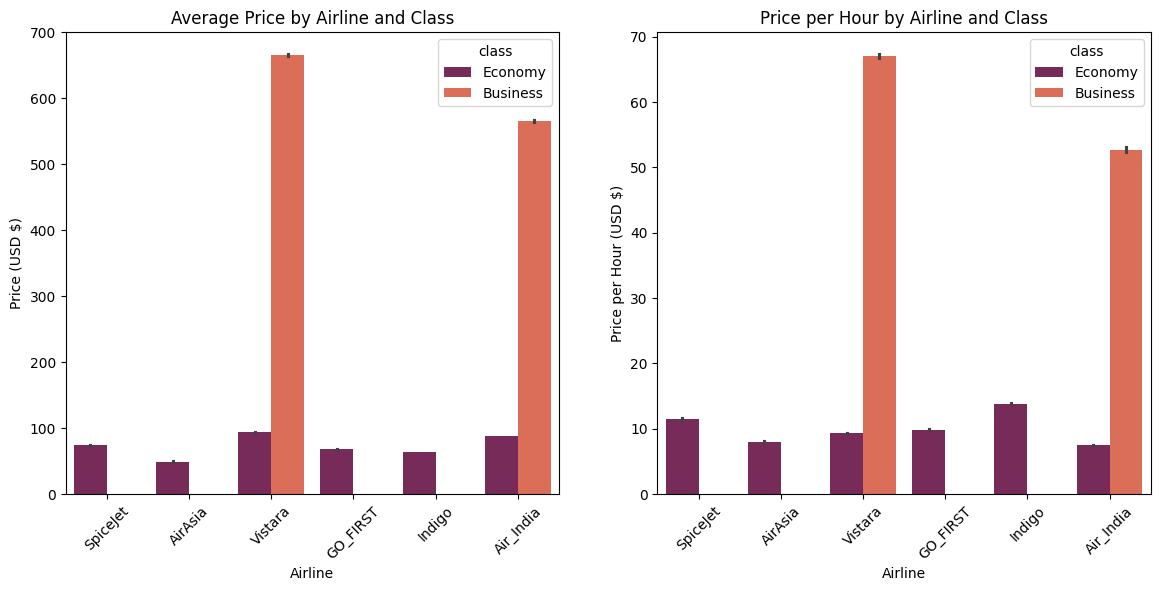

In [22]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='airline', y='price (USD $)', data=df_cleaned, hue='class', palette='rocket')
plt.title('Average Price by Airline and Class')
plt.xlabel('Airline')
plt.ylabel('Price (USD $)')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(x='airline', y='price per hour (USD $)', data=df_cleaned, hue='class', palette='rocket')
plt.title('Price per Hour by Airline and Class')
plt.xlabel('Airline')
plt.ylabel('Price per Hour (USD $)')
plt.xticks(rotation=45)

plt.show()

Air India has the lowest $ cost per hour while Indigo has the highest, indicating that once flight time is considered, the seemingly more expensive airlines are actually more cost efficient on an hourly basis. This helps passengers save money when booking and gives airlines more context when comparing operational efficiency.

## Depature and Arrival Time Price Variation Analysis
Let's see if the flight timing might be a correlating factor for the price or airline variables while only counting tickets in economy class.

In [26]:
df_cleaned[df_cleaned['class'] == 'Economy'].groupby('departure_time')['price'].mean()


departure_time
Afternoon        6473.095872
Early_Morning    6560.315392
Evening          6360.750741
Late_Night       4784.699486
Morning          7119.019664
Night            6205.964764
Name: price, dtype: float64

Looks like the prices are mostly similar across timings, with late night being the least expensive.